# Day 3 Walkthrough: Measuring Something In An Image

Yesterday every value arrived in a column with a name. Today the data is a grid
of brightnesses with no names at all, and the quantity we want is not stored
anywhere in it. A tumour has an area, and that area has to be constructed out
of pixels by a chain of decisions that nobody writes down.

That is the argument of this hour. Image processing looks unusually
trustworthy, because at every step you can display the result and see that it
looks right. A picture that looks right is not a measurement that is right, and
this hour ends with a number that is wrong by seventy-five percent while every
picture along the way looked perfect.

The data is 844 T1-weighted contrast-enhanced MRI slices from 66 patients, each
with a tumour outlined by a radiologist. A single slice is enough for the whole
walkthrough.

| Section | Minutes |
| --- | --- |
| Orientation | 3 |
| 1. What An MRI Slice Actually Is | 7 |
| 2. Intensity, Histograms, And Thresholding | 11 |
| 3. Morphology And Connected Components | 10 |
| 4. Measuring A Region In Millimetres | 12 |
| 5. From A Kernel You Wrote To A Layer That Learns One | 13 |
| 6. What To Take Away | 4 |

## Orientation (3 Minutes)

The habits from the first two days still apply. Restart the kernel and run
every cell in order if anything stops making sense, read the minimum and the
maximum before trusting an array, and print a baseline next to every number you
intend to interpret.

Two habits are new today.

The first is that an image is an array, and the fastest way to understand what
an operation did is to print the array's shape, its dtype, and its range rather
than to look at the picture. The picture is a rendering, and the rendering
hides things such as an integer overflow or a channel order that is the wrong
way round.

The second is that every measurement taken from an image depends on the
physical size of a pixel, which is not stored in the pixels. Lose that number
and the measurement is meaningless, and nothing in the code will complain.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

# Every notebook resolves its data through a path relative to itself, so the
# materials work the same way on JupyterHub and on a laptop.
DATA_DIR = Path.cwd().parent / "data"
SLICE_DIR = DATA_DIR / "slices"
MASK_DIR = DATA_DIR / "masks"

RANDOM_STATE = 42

# The archive records an in-plane resolution of 0.49 by 0.49 millimetres for
# every 512 by 512 slice. This one number turns pixel counts into areas, and
# Section 4 is about how easily it stops being true.
PIXEL_MM = 0.49

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 110)

print("Reading data from:", DATA_DIR)
print("Slices found:", len(list(SLICE_DIR.glob("*.jpg"))))
print("Masks found: ", len(list(MASK_DIR.glob("*.png"))))
print("OpenCV:", cv2.__version__, "| PyTorch:", torch.__version__)

Reading data from: /Users/dimitar.peshevski/workspace/ml-workshop/Day 3 - Image Processing and Analysis/data
Slices found: 844
Masks found:  844
OpenCV: 5.0.0 | PyTorch: 2.11.0


## 1. What An MRI Slice Actually Is (7 Minutes)

The index names every slice, the patient it came from, and the tumour type.
Read it before reading any pixels.

In [2]:
slices = pd.read_csv(DATA_DIR / "slices.csv", dtype={"patient_id": str})

print("Rows:", len(slices))
print("Patients:", slices["patient_id"].nunique())
slices.head()

Rows: 844
Patients: 66


,file,patient_id,tumor_type
0,meningioma_100572_0006.jpg,100572,meningioma
1,meningioma_100572_0007.jpg,100572,meningioma
2,meningioma_100572_0008.jpg,100572,meningioma
3,meningioma_100572_0218.jpg,100572,meningioma
4,meningioma_100572_0219.jpg,100572,meningioma


In [3]:
print(slices.groupby("tumor_type").agg(
    slices=("file", "size"),
    patients=("patient_id", "nunique"),
))

            slices  patients
tumor_type                  
glioma         291        22
meningioma     274        22
pituitary      279        22


Three tumour types, roughly balanced, and 22 patients in each. Note that
patients and slices are different units. There are 844 slices but only 66
people, so most slices have a sibling from the same person somewhere else in
the table. Hold on to that, because it is the whole subject of the laboratory
exercise this afternoon.

Now read one image. `cv2.imread` returns `None` rather than raising when it
cannot read a file, so the assertion below is not decoration.

In [4]:
demo_name = "meningioma_101016_0011.jpg"

image = cv2.imread(str(SLICE_DIR / demo_name), cv2.IMREAD_GRAYSCALE)
assert image is not None, f"could not read {demo_name}"

print("shape:", image.shape)
print("dtype:", image.dtype)
print("min:  ", image.min())
print("max:  ", image.max())
print("mean: ", round(float(image.mean()), 2))
print("pixels that are exactly zero:",
      f"{(image == 0).mean() * 100:.1f}% of the image")

shape: (512, 512)
dtype: uint8
min:   0
max:   254
mean:  22.19
pixels that are exactly zero: 28.1% of the image


A 512 by 512 array of unsigned bytes, spanning very nearly the full range from
0 to 255. Just over a quarter of it is exactly zero, which is the air around
the head, and that block of zeros dominates several of the operations below.

The flag matters. Without `cv2.IMREAD_GRAYSCALE` you get three channels, and
OpenCV orders them blue, green, and red rather than the red, green, and blue
that everything else assumes. That reversal is the single most common source of
images that come out looking wrong.

In [5]:
colour = cv2.imread(str(SLICE_DIR / demo_name))
print("with the flag:   ", image.shape)
print("without the flag:", colour.shape)
# The three channels of a grey image are identical, so nothing is lost here,
# but the channel order still bites the moment a colour overlay is drawn.
print("channels identical:", np.array_equal(colour[:, :, 0], colour[:, :, 2]))

with the flag:    (512, 512)
without the flag: (512, 512, 3)
channels identical: True


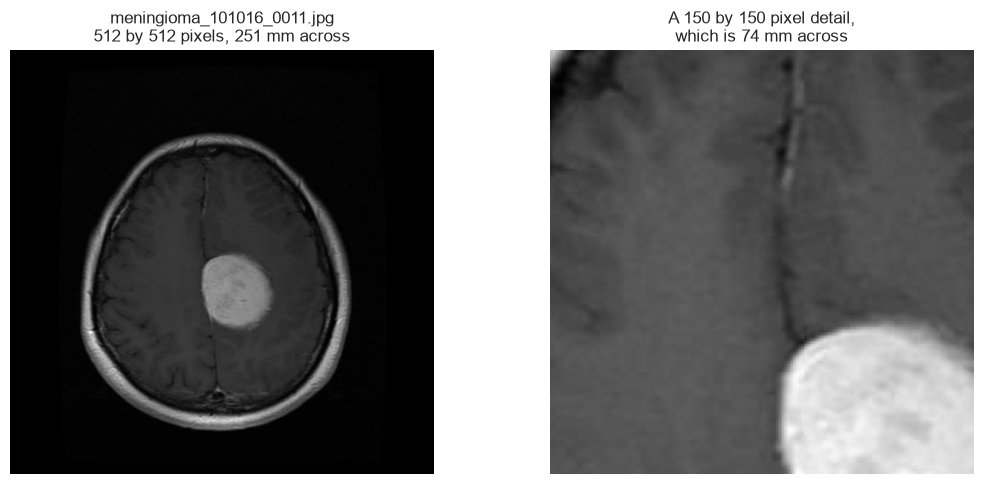

One pixel is 0.49 mm, so the slice is 250.9 mm wide.
One pixel covers 0.2401 square millimetres.


In [6]:
side_mm = image.shape[0] * PIXEL_MM

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"{demo_name}\n{image.shape[1]} by {image.shape[0]} pixels, "
                  f"{side_mm:.0f} mm across")
axes[0].axis("off")
axes[1].imshow(image[150:300, 150:300], cmap="gray")
axes[1].set_title("A 150 by 150 pixel detail,\nwhich is "
                  f"{150 * PIXEL_MM:.0f} mm across")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"One pixel is {PIXEL_MM} mm, so the slice is {side_mm:.1f} mm wide.")
print(f"One pixel covers {PIXEL_MM ** 2:.4f} square millimetres.")

The bright mass on the left of the image is a meningioma. It is bright because
this is a contrast-enhanced scan and the agent collects where the tumour is, and
that single fact is what every method in the next two sections quietly relies
on.

## 2. Intensity, Histograms, And Thresholding (11 Minutes)

Separating an object from its surroundings by choosing a brightness cutoff is
called thresholding. The question is what cutoff, and the histogram is where
you look for the answer.

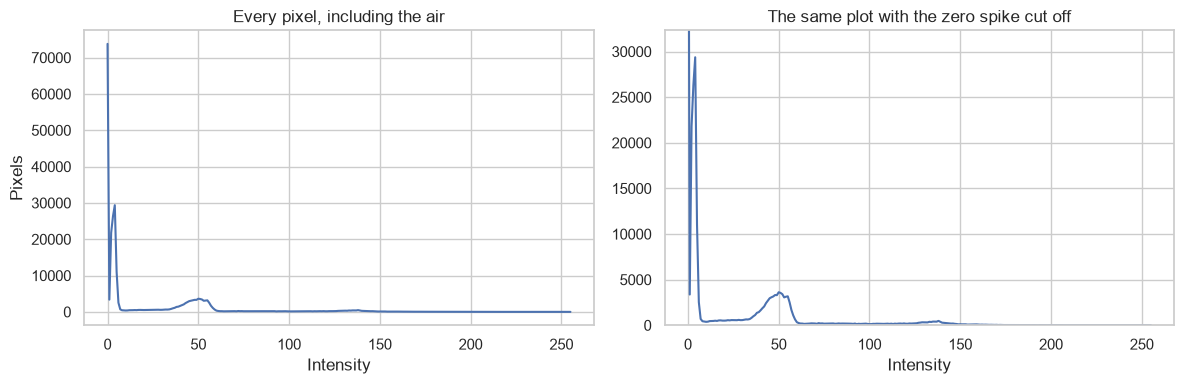

pixels at intensity 0: 73789
largest count anywhere else: 29373


In [7]:
histogram = cv2.calcHist([image], [0], None, [256], [0, 256]).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(histogram)
axes[0].set_title("Every pixel, including the air")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Pixels")
axes[1].plot(histogram)
axes[1].set_ylim(0, np.sort(histogram)[-2] * 1.1)
axes[1].set_title("The same plot with the zero spike cut off")
axes[1].set_xlabel("Intensity")
plt.tight_layout()
plt.show()

print("pixels at intensity 0:", int(histogram[0]))
print("largest count anywhere else:", int(np.sort(histogram)[-2]))

The left plot is useless, and it is useless in a way worth seeing once. One bar
holds a quarter of the image and flattens everything else into the axis. The
right plot is the same data with that bar cropped, and only now is there
anything to read.

Otsu's method picks the cutoff that best separates the pixels into two groups.
It assumes there are two groups. Let us see which two it finds.

Otsu chose a threshold of 34.
Pixels above it: 78995 (30.1% of the image)


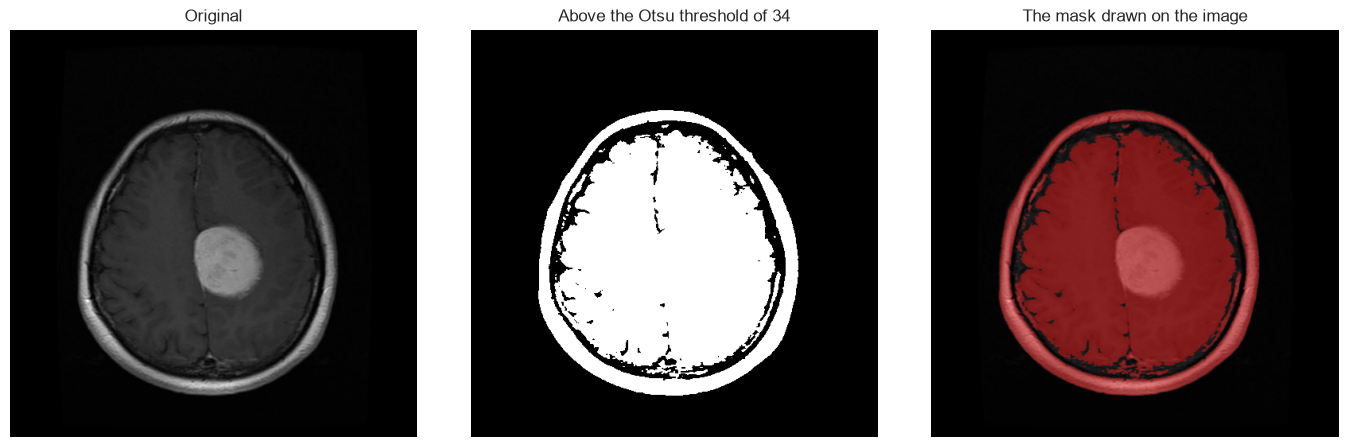

In [8]:
threshold, binary = cv2.threshold(image, 0, 255, cv2.THRESH_OTSU)

print(f"Otsu chose a threshold of {threshold:.0f}.")
print(f"Pixels above it: {(image > threshold).sum()} "
      f"({(image > threshold).mean() * 100:.1f}% of the image)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title(f"Above the Otsu threshold of {threshold:.0f}")
# Drawing the mask over the image in colour requires a three-channel image, and
# OpenCV expects those channels in blue, green, and red order.
overlay = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
overlay[binary > 0] = (0.6 * overlay[binary > 0] +
                       0.4 * np.array([0, 0, 255])).astype(np.uint8)
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title("The mask drawn on the image")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Read what happened rather than what we wanted. Otsu separated the head from the
air. It did not separate the tumour from the brain, and it never could have,
because the two brightness groups in this image are tissue and background, and
the tumour is a small part of the first group.

This is the shape of almost every disappointment in image processing. The
method did exactly what it promises. The promise was about a different question
from the one we are asking.

Otsu is still useful here, just not for the tumour. It has given us the head,
and the next section turns that into a usable region.

## 3. Morphology And Connected Components (10 Minutes)

A binary mask is a set of pixels. Connected component labelling turns it into a
set of objects, by giving every group of touching pixels its own number.

In [9]:
count, markers = cv2.connectedComponents(binary)

# Label 0 is the background, so the real objects are 1 up to count - 1.
areas = np.array([(markers == label).sum() for label in range(1, count)])
order = np.argsort(areas)[::-1]

print(f"{count - 1} objects above the threshold.")
print("The five largest, in pixels:", areas[order][:5].tolist())
print(f"The largest covers {areas.max() / image.size * 100:.1f}% of the image, "
      f"which is {areas.max() * PIXEL_MM ** 2 / 100:.1f} square centimetres.")

27 objects above the threshold.
The five largest, in pixels: [78526, 207, 54, 28, 28]
The largest covers 30.0% of the image, which is 188.5 square centimetres.


One object is enormous and the rest are specks of a few hundred pixels or
fewer. The large one is the head. The specks are noise that crossed the
threshold, and they are exactly what morphology removes.

The two primitive operations are erosion, which deletes any foreground pixel
whose neighbourhood is not entirely foreground, and dilation, which does the
reverse. Composing them gives opening, which is an erosion followed by a
dilation, and it removes small objects while leaving large ones close to their
original size.

original  foreground   78995 px, objects  27
eroded    foreground   66896 px, objects  17
dilated   foreground   90106 px, objects   3
opened    foreground   77495 px, objects   8


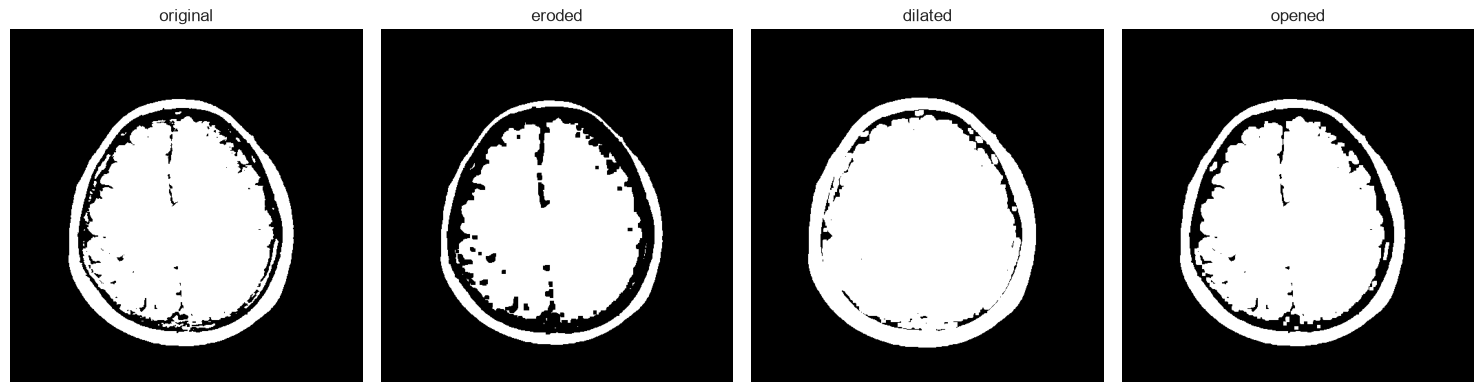

In [10]:
kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(binary, kernel)
dilated = cv2.dilate(binary, kernel)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

for name, result in [("original", binary), ("eroded", eroded),
                     ("dilated", dilated), ("opened", opened)]:
    objects = cv2.connectedComponents(result)[0] - 1
    print(f"{name:9s} foreground {result.astype(bool).sum():7d} px, "
          f"objects {objects:3d}")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (name, result) in zip(axes, [("original", binary), ("eroded", eroded),
                                     ("dilated", dilated), ("opened", opened)]):
    ax.imshow(result, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

Opening cut the object count from 27 to 8 while removing under two percent of
the foreground, because the head is far larger than the kernel and the specks
are smaller than it. That asymmetry is the whole point of the operation.
Erosion alone shrinks everything, and dilation alone merged the specks into the
head rather than deleting them.

For the rest of the walkthrough we want the brain rather than the head, and the
difference matters. The skull and the fat beneath the scalp are the brightest
things in the image, brighter than the tumour is, so any method that looks for
bright pixels finds the skull first. Eroding the head mask hard pushes the
boundary inward past that rim, and the cell below prints the brightest value on
each side of it so you can see the size of the problem.

head   81420 px
brain  45417 px after eroding by a 35 pixel ellipse, which is 56% of the head
brightest pixel in the head:  254
brightest pixel in the brain: 165


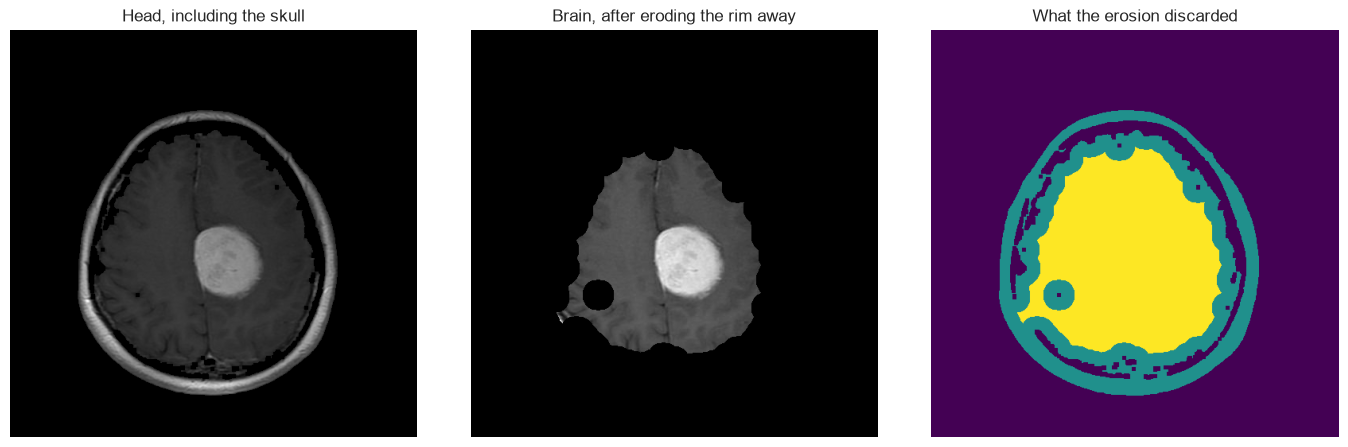

In [11]:
def head_mask(gray):
    """Return the largest connected object above the Otsu threshold."""
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    # Closing first, so that a dark vessel inside the head does not split it.
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    count, markers = cv2.connectedComponents(mask)
    if count < 2:
        return np.ones(gray.shape, bool)
    sizes = [(markers == label).sum() for label in range(1, count)]
    return markers == int(np.argmax(sizes)) + 1


head = head_mask(image)
ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
brain = cv2.erode(head.astype(np.uint8), ellipse) > 0

print(f"head  {head.sum():6d} px")
print(f"brain {brain.sum():6d} px after eroding by a 35 pixel ellipse, "
      f"which is {brain.sum() / head.sum() * 100:.0f}% of the head")
print("brightest pixel in the head: ", image[head].max())
print("brightest pixel in the brain:", image[brain].max())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(np.where(head, image, 0), cmap="gray")
axes[0].set_title("Head, including the skull")
axes[1].imshow(np.where(brain, image, 0), cmap="gray")
axes[1].set_title("Brain, after eroding the rim away")
axes[2].imshow(head.astype(int) + brain.astype(int), cmap="viridis")
axes[2].set_title("What the erosion discarded")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The erosion is crude. It throws away a ring of real brain along with the skull,
and on a slice where the tumour touches the edge of the brain it would throw
away part of the tumour too. It is kept because it is simple and because the
laboratory exercise measures what it costs, which is the honest way to use a
method you know to be approximate.

## 4. Measuring A Region In Millimetres (12 Minutes)

Now the actual task. Inside the brain, group pixels by brightness into three
clusters and take the brightest one, on the assumption that the enhancing
tumour is the brightest tissue present.

In [12]:
def segment_tumour(gray, erode_px=35, clusters=3, open_px=5):
    """Segment the brightest region inside the brain and return a mask.

    OpenCV's k-means draws its starting centres from a global random number
    generator, so it is reseeded here. Without this the same slice gives
    slightly different centres on a second call, and every number derived from
    it moves.
    """
    cv2.setRNGSeed(RANDOM_STATE)

    inside = cv2.erode(head_mask(gray).astype(np.uint8),
                       cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                                 (erode_px, erode_px))) > 0
    if inside.sum() < clusters:
        return np.zeros(gray.shape, bool)

    blurred = cv2.GaussianBlur(np.where(inside, gray, 0), (5, 5), 0)
    samples = blurred[inside].reshape(-1, 1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    _, labels, centres = cv2.kmeans(samples, clusters, None, criteria, 10,
                                    cv2.KMEANS_PP_CENTERS)

    grouped = np.full(gray.shape, -1, int)
    grouped[inside] = labels.ravel()
    brightest = (grouped == int(np.argmax(centres.ravel()))).astype(np.uint8) * 255
    brightest = cv2.morphologyEx(brightest, cv2.MORPH_OPEN,
                                 np.ones((open_px, open_px), np.uint8))

    # findContours needs an 8-bit array rather than a boolean one, and
    # `brightest` already holds 0 and 255.
    contours, _ = cv2.findContours(brightest, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    result = np.zeros(gray.shape, np.uint8)
    if contours:
        cv2.drawContours(result, [max(contours, key=cv2.contourArea)], -1, 255,
                         cv2.FILLED)
    return result > 127


predicted = segment_tumour(image)

print("predicted tumour:", predicted.sum(), "px")
print(f"which is {predicted.sum() * PIXEL_MM ** 2:.0f} square millimetres")

predicted tumour: 5715 px
which is 1372 square millimetres


A number. It is worth pausing on how little that proves. Nothing in the
computation could have failed, and it would have produced a number just as
confidently on a slice with no tumour at all.

This dataset has the one thing that makes the number checkable, which is a
boundary drawn by a radiologist for every slice.

radiologist:   6121 px =    1470 mm2
pipeline:      5715 px =    1372 mm2
Dice overlap: 0.957


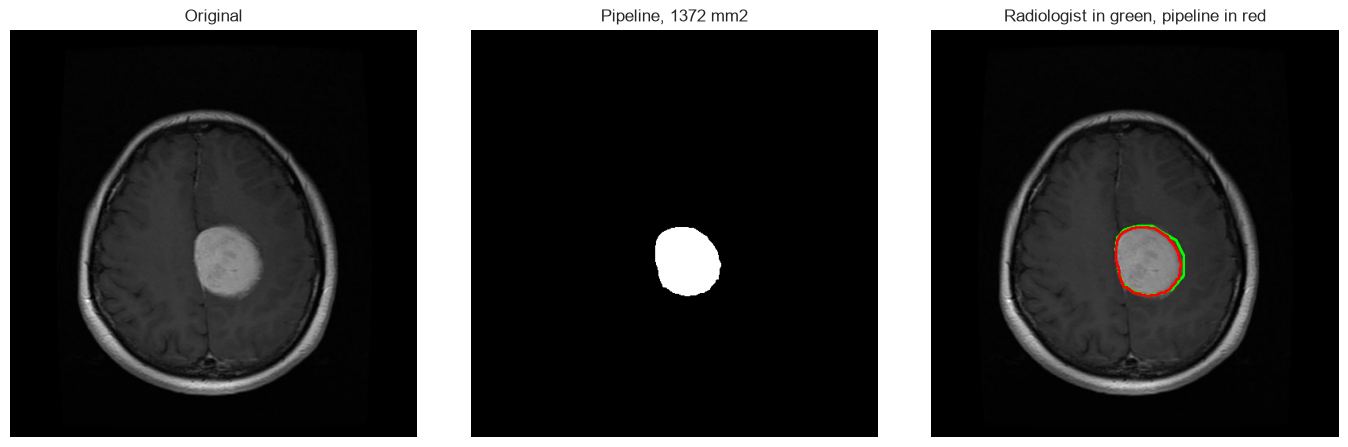

In [13]:
truth = cv2.imread(str(MASK_DIR / demo_name.replace(".jpg", ".png")),
                   cv2.IMREAD_GRAYSCALE) > 127


def dice(a, b):
    """Overlap between two boolean masks, from 0 for none to 1 for identical."""
    total = a.sum() + b.sum()
    return 2 * (a & b).sum() / total if total else 0.0


print(f"radiologist: {truth.sum():6d} px = {truth.sum() * PIXEL_MM ** 2:7.0f} mm2")
print(f"pipeline:    {predicted.sum():6d} px = "
      f"{predicted.sum() * PIXEL_MM ** 2:7.0f} mm2")
print(f"Dice overlap: {dice(predicted, truth):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(predicted, cmap="gray")
axes[1].set_title(f"Pipeline, {predicted.sum() * PIXEL_MM ** 2:.0f} mm2")
outline = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
for mask, colour_bgr in [(truth, (0, 255, 0)), (predicted, (0, 0, 255))]:
    found, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(outline, found, -1, colour_bgr, 2)
axes[2].imshow(cv2.cvtColor(outline, cv2.COLOR_BGR2RGB))
axes[2].set_title("Radiologist in green, pipeline in red")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

On this slice the two outlines very nearly coincide. That is a genuinely good
result, and it is also the reason this slice was chosen for a demonstration.
The laboratory exercise runs the same pipeline over all 844 slices, and the
picture there is different enough to be the point of the afternoon.

### The Number That Is Wrong By Seventy-Five Percent

Resizing an image is the most ordinary operation in the whole toolkit. Every
model wants a fixed input size, so almost every pipeline contains a resize.

Take the radiologist's mask, which we know to be right, and shrink it to 256 by
256. No segmentation is involved, so nothing can go wrong except the
arithmetic.

In [14]:
small_truth = cv2.resize(truth.astype(np.uint8), (256, 256),
                         interpolation=cv2.INTER_NEAREST) > 0

# Halving the width of the image doubles the ground each pixel covers, so the
# spacing has to be scaled by the same factor the resize applied.
scale = image.shape[0] / small_truth.shape[0]

full = truth.sum() * PIXEL_MM ** 2
careless = small_truth.sum() * PIXEL_MM ** 2
corrected = small_truth.sum() * (PIXEL_MM * scale) ** 2

print(f"at 512, {truth.sum():5d} px with 0.49 mm pixels        = {full:7.0f} mm2")
print(f"at 256, {small_truth.sum():5d} px with 0.49 mm pixels        = "
      f"{careless:7.0f} mm2  <- wrong")
print(f"at 256, {small_truth.sum():5d} px with {PIXEL_MM * scale:.2f} mm pixels        = "
      f"{corrected:7.0f} mm2")
print()
print(f"keeping the old spacing is {careless / full - 1:+.1%}")
print(f"scaling the spacing is     {corrected / full - 1:+.1%}")

at 512,  6121 px with 0.49 mm pixels        =    1470 mm2
at 256,  1528 px with 0.49 mm pixels        =     367 mm2  <- wrong
at 256,  1528 px with 0.98 mm pixels        =    1467 mm2

keeping the old spacing is -75.0%
scaling the spacing is     -0.1%


Three quarters of the tumour disappeared and every picture still looks
correct. The resized mask is the same shape in the same place, and the only
thing that changed is a number that appears nowhere in the arrays. Area scales
with the square of a length, the resize halved the length, so the area fell by
a factor of four. Scaling the spacing recovers the original figure to within a
rounding error.

There is a second way a resize damages a measurement, and it is not fixed by
scaling a number. This pipeline erodes by 35 pixels, and 35 pixels is a
different distance on a smaller image, so the pipeline does not merely
mis-scale its answer, it finds a different region.

In [15]:
small_image = cv2.resize(image, (256, 256))
small_predicted = segment_tumour(small_image)

at_full = predicted.sum() * PIXEL_MM ** 2
rescaled = small_predicted.sum() * (PIXEL_MM * scale) ** 2

print(f"segmenting at 512:                    {predicted.sum():5d} px = "
      f"{at_full:7.0f} mm2")
print(f"segmenting at 256, spacing scaled:    {small_predicted.sum():5d} px = "
      f"{rescaled:7.0f} mm2")
print(f"difference: {rescaled / at_full - 1:+.1%}, with the spacing already correct")
print()
print("A parameter measured in pixels is a parameter measured in millimetres")
print("that forgot to say so.")

segmenting at 512:                     5715 px =    1372 mm2
segmenting at 256, spacing scaled:     1270 px =    1220 mm2
difference: -11.1%, with the spacing already correct

A parameter measured in pixels is a parameter measured in millimetres
that forgot to say so.


So a resize costs a factor of four through the spacing, which is arithmetic you
can repair, and a further ten percent or so through every parameter in the
pipeline that was expressed in pixels, which you cannot repair without
rethinking the parameter.

For contrast, here is an error that feels like the dangerous one and is not.
Using a round 0.5 millimetres instead of the recorded 0.49 is the kind of
sloppiness that gets caught in review.

In [16]:
recorded = predicted.sum() * PIXEL_MM ** 2
rounded = predicted.sum() * 0.5 ** 2

print(f"with the recorded 0.49 mm: {recorded:.0f} mm2")
print(f"with a round 0.5 mm:       {rounded:.0f} mm2  ({rounded / recorded - 1:+.1%})")
print()
print("Rounding the spacing costs four percent. Forgetting that a resize")
print("changes it costs seventy-five percent.")

with the recorded 0.49 mm: 1372 mm2
with a round 0.5 mm:       1429 mm2  (+4.1%)

Rounding the spacing costs four percent. Forgetting that a resize
changes it costs seventy-five percent.


## 5. From A Kernel You Wrote To A Layer That Learns One (13 Minutes)

Everything so far has been thresholds and shapes chosen by hand. This afternoon
uses a convolutional network instead, and the gap between the two is smaller
than it looks.

Filtering an image means sliding a small grid of weights over it and replacing
each pixel with the weighted sum of its neighbours. Here is a filter that
responds to vertical edges, written out by hand.

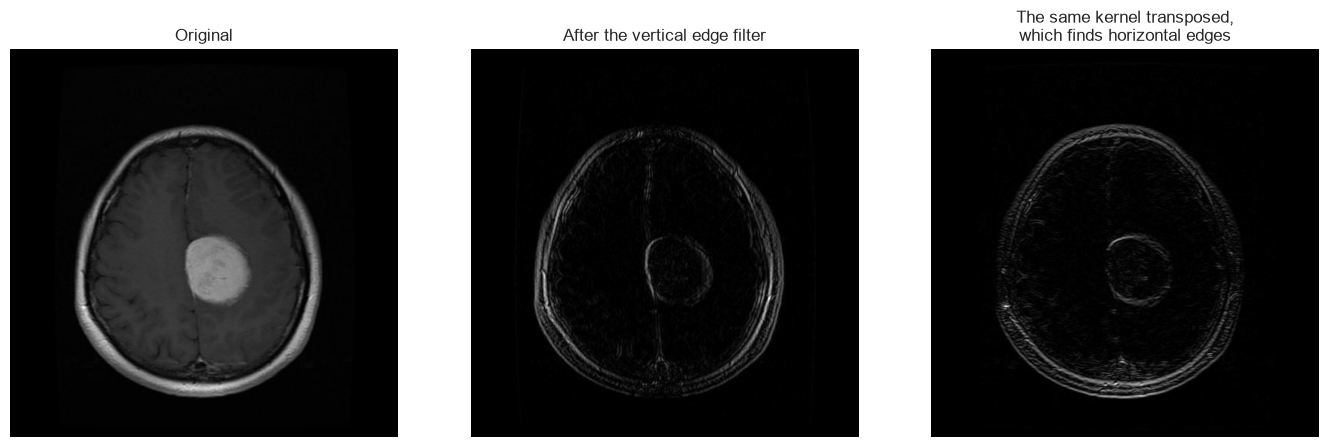

In [17]:
edge_kernel = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32)

filtered = cv2.filter2D(image.astype(np.float32), -1, edge_kernel,
                        borderType=cv2.BORDER_REPLICATE)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.abs(filtered), cmap="gray")
axes[1].set_title("After the vertical edge filter")
axes[2].imshow(np.abs(cv2.filter2D(image.astype(np.float32), -1,
                                   edge_kernel.T,
                                   borderType=cv2.BORDER_REPLICATE)),
               cmap="gray")
axes[2].set_title("The same kernel transposed,\nwhich finds horizontal edges")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Now the same operation as a PyTorch layer, with the weights set to the numbers
we just typed. If a convolutional layer is really doing what `filter2D` does,
the two outputs should agree exactly rather than approximately.

In [18]:
layer = torch.nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3,
                        padding=1, padding_mode="replicate", bias=False)
with torch.no_grad():
    layer.weight.copy_(torch.from_numpy(edge_kernel)[None, None])

as_tensor = torch.from_numpy(image.astype(np.float32))[None, None]
with torch.no_grad():
    by_torch = layer(as_tensor)[0, 0].numpy()

print("largest absolute difference:", np.abs(filtered - by_torch).max())
print("identical:", np.array_equal(filtered, by_torch))

largest absolute difference: 0.0
identical: True


Bit for bit the same operation. The only difference between this and the
network trained this afternoon is where the nine numbers come from. Here they
were chosen because somebody worked out what detects a vertical edge. In a
convolutional network they start as noise and are adjusted until they detect
whatever reduces the loss, and a network has thousands of them stacked in
layers.

That is worth saying plainly, because it cuts a convolutional network down to a
size that fits in the head. It is a stack of the filters from Section 4, with
the weights fitted instead of written.

Here is what an untrained layer's filters do, which is very close to nothing.

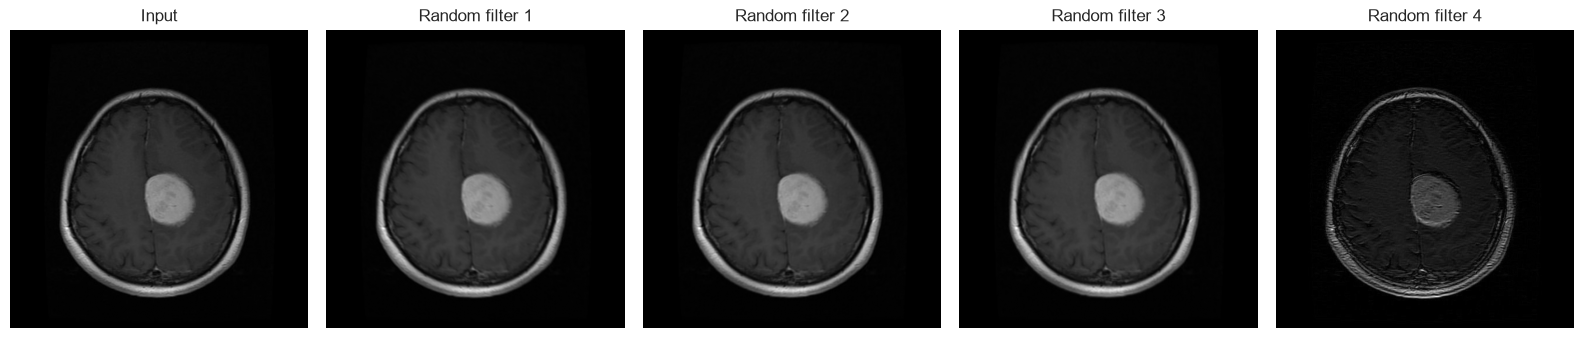

The first random filter's nine weights:
[[ 0.255  0.277 -0.078]
 [ 0.306 -0.073  0.067]
 [-0.162  0.196  0.294]]


In [19]:
torch.manual_seed(RANDOM_STATE)
untrained = torch.nn.Conv2d(1, 4, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    responses = untrained(as_tensor)[0].numpy()

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Input")
axes[0].axis("off")
for i in range(4):
    axes[i + 1].imshow(np.abs(responses[i]), cmap="gray")
    weights = untrained.weight[i, 0].detach().numpy().round(2)
    axes[i + 1].set_title(f"Random filter {i + 1}")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()

print("The first random filter's nine weights:")
print(untrained.weight[0, 0].detach().numpy().round(3))

### Making The Weights Stop Being Noise

Nothing above learned anything. To learn, a layer needs something to be wrong
about, a way to measure how wrong, and a rule for changing the weights to be
less wrong. That is the whole of training.

Here is the smallest honest version. Start a filter from noise, and adjust its
nine weights until its output matches the picture the hand-written kernel
produced. We know the answer this time, which is the point.

In [20]:
torch.manual_seed(RANDOM_STATE)
learner = torch.nn.Conv2d(1, 1, kernel_size=3, padding=1,
                          padding_mode="replicate", bias=False)

# Scaling to the unit interval keeps the loss a readable size.
inputs = torch.from_numpy(image.astype(np.float32) / 255.0)[None, None]
target = torch.from_numpy(filtered / 255.0)[None, None]

optimiser = torch.optim.Adam(learner.parameters(), lr=0.2)

print("before training, the nine weights are noise:")
print(learner.weight[0, 0].detach().numpy().round(3))
print()

for step in range(400):
    optimiser.zero_grad()
    loss = torch.nn.functional.mse_loss(learner(inputs), target)
    loss.backward()
    optimiser.step()
    if step % 80 == 0:
        print(f"  step {step:3d}  loss {loss.item():.3e}")

learned = learner.weight[0, 0].detach().numpy()
with torch.no_grad():
    fitted = learner(inputs)[0, 0].numpy()

print(f"  step 400  loss {loss.item():.3e}")
print("\nafter training:")
print(learned.round(3))
print("\nthe kernel we wrote by hand:")
print(edge_kernel)

before training, the nine weights are noise:
[[ 0.255  0.277 -0.078]
 [ 0.306 -0.073  0.067]
 [-0.162  0.196  0.294]]

  step   0  loss 4.365e-02
  step  80  loss 6.573e-05
  step 160  loss 1.810e-05


  step 240  loss 1.493e-05
  step 320  loss 1.249e-05
  step 400  loss 1.070e-05

after training:
[[-1.33   0.119  1.216]
 [-1.293 -0.167  1.449]
 [-1.424  0.095  1.336]]

the kernel we wrote by hand:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]


Read the loss first. It fell by more than three orders of magnitude and
finished near ten to the minus five, which for a quantity that started at
0.044 means the fit is essentially exact.

Now read the weights, which are not the kernel we wrote. The signs are right
and the shape is right, a negative column on the left and a positive one on the
right, but the numbers are wrong by up to 0.7.

Both of those readings are correct, and the next cell says how.

agreement between the two pictures: 0.999601
largest single weight error:        0.707


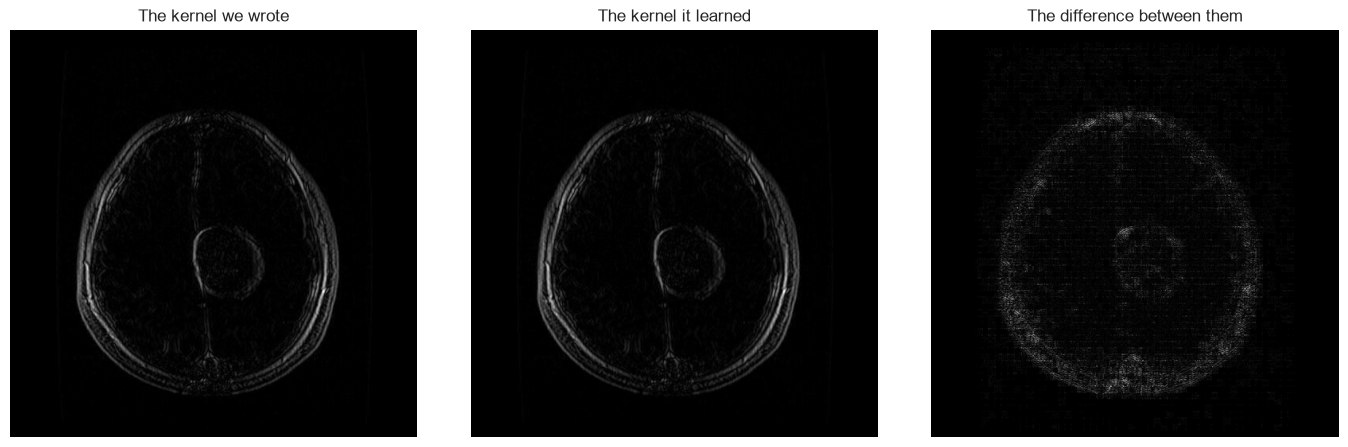

In [21]:
print("agreement between the two pictures: "
      f"{np.corrcoef(fitted.ravel(), (filtered / 255.0).ravel())[0, 1]:.6f}")
print(f"largest single weight error:        {np.abs(learned - edge_kernel).max():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(np.abs(filtered), cmap="gray")
axes[0].set_title("The kernel we wrote")
axes[1].imshow(np.abs(fitted * 255.0), cmap="gray")
axes[1].set_title("The kernel it learned")
axes[2].imshow(np.abs(filtered - fitted * 255.0), cmap="gray")
axes[2].set_title("The difference between them")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

The two pictures correlate at 0.9996 and are hard to tell apart by eye, while
the weights that produced them differ by as much as 0.707. That is not a bug in
the training, and running it longer does not fix it.

The reason is a property of the input rather than of the method. A convolution
mixes nine shifted copies of the image, and in an MRI slice a pixel and its
neighbour are almost the same number, so those nine copies are nearly
interchangeable. Many different sets of nine weights therefore produce almost
the same picture, and gradient descent stops at whichever one it reached first.

If that is really the explanation, then feeding the same procedure an input
whose neighbouring pixels are unrelated should recover the kernel exactly.
Nothing else changes.

In [22]:
rng = np.random.default_rng(RANDOM_STATE)
noise = rng.standard_normal((512, 512)).astype(np.float32)
noise_target = cv2.filter2D(noise, -1, edge_kernel,
                            borderType=cv2.BORDER_REPLICATE)

torch.manual_seed(RANDOM_STATE)
on_noise = torch.nn.Conv2d(1, 1, kernel_size=3, padding=1,
                           padding_mode="replicate", bias=False)
optimiser = torch.optim.Adam(on_noise.parameters(), lr=0.2)

for step in range(400):
    optimiser.zero_grad()
    loss = torch.nn.functional.mse_loss(
        on_noise(torch.from_numpy(noise)[None, None]),
        torch.from_numpy(noise_target)[None, None])
    loss.backward()
    optimiser.step()

recovered = on_noise.weight[0, 0].detach().numpy()
print(f"final loss: {loss.item():.3e}")
print("recovered kernel:")
print(recovered.round(3))
print(f"largest single weight error: {np.abs(recovered - edge_kernel).max():.4f}")

final loss: 2.114e-18
recovered kernel:
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1. -0.  1.]]
largest single weight error: 0.0000


Exactly the kernel we wrote, to every decimal place shown. The method was never
in doubt. The MRI simply did not contain enough independent evidence to pin
down nine numbers, and the measurement below says how much is missing.

In [23]:
def identifiability(array):
    """How independent are the nine shifted copies a 3 by 3 kernel mixes?

    Returns the condition number of their Gram matrix. A value near 1 means all
    nine weights can be pinned down. A large value means many different kernels
    fit the data about equally well.
    """
    shifted = [np.roll(np.roll(array, dy, 0), dx, 1).ravel()
               for dy in (-1, 0, 1) for dx in (-1, 0, 1)]
    stacked = np.stack(shifted, axis=1)
    return np.linalg.cond(stacked.T @ stacked / len(stacked))


print(f"MRI slice:   {identifiability(image.astype(np.float64) / 255):14,.0f}")
print(f"white noise: {identifiability(noise.astype(np.float64)):14,.1f}")

MRI slice:          124,210
white noise:            1.0


That is the second time this hour a number has looked convincing while the
thing it was supposed to describe was wrong. In Section 4 an area computed after
a resize was out by a factor of four while every picture stayed plausible. Here a
loss of ten to the minus five sits on top of weights that are not the ones that
generated the data.

The network this afternoon has about twenty-six thousand weights rather than
nine, and it trains on 844 images rather than one. Nobody will inspect those
weights, and nobody could read them if they did. The only thing you will have is
a number saying how well it did, which is the situation this cell has just shown
to be untrustworthy on its own. Deciding when such a number can be believed is
the work of the afternoon.

In [24]:
def pick_device():
    """Use a GPU when the image provides one, and fall back sensibly."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


print("This session will train on:", pick_device())

This session will train on: mps


## 6. What To Take Away (4 Minutes)

- An image is an array. Print its shape, dtype, and range before trusting a
  rendering of it, because the rendering hides the errors that matter.
- Otsu's method separates two brightness groups, and on an MRI slice those
  groups are the head and the air. It is the right tool for finding the head
  and it can never find the tumour.
- Opening removes objects smaller than its kernel and leaves larger ones nearly
  untouched, which is why it cleans a mask without shrinking the thing you
  wanted.
- The skull is brighter than the tumour, so any method that hunts for bright
  pixels finds the skull unless you remove it first.
- A measurement in millimetres depends on a number that is not in the image. A
  resize silently invalidates it, and the resulting error is squared for an
  area.
- Check a segmentation against a boundary somebody drew, and quote the overlap.
  A mask that looks plausible is not evidence, and this pipeline produced a
  confident number on the one slice it was tuned for.
- A convolutional layer is the hand-written filter from Section 5 with its
  weights fitted rather than chosen. That is the whole idea.
- Training is a loss, a gradient, and a step, repeated. Nine weights are enough
  to see all three at once.
- A loss near zero says the output matches. It does not say the weights are
  right, and when the input's own columns are nearly interchangeable it cannot.

The laboratory exercise takes this pipeline, which just scored a Dice of about
0.96, and runs it over every slice in the dataset.